# Examen: Matrices Estocasticas y Simulacion en Qiskit

| Informacion | Detalle |
|---|---|
| **Curso** | Computacion Cuantica |
| **Guia** | Guia 04 - Matrices Estocasticas y Canales Cuanticos |
| **Herramientas** | Python 3, NumPy, Matplotlib, Qiskit, IBM Quantum |

---

## Instrucciones

- Justifique todos sus procedimientos.
- Puede apoyarse en Python y Qiskit para los calculos.
- Interprete los resultados obtenidos.

---

## Marco Teorico General

### 1. Cadenas de Markov
Una cadena de Markov es un proceso estocastico que modela la evolucion de un sistema entre un conjunto finito de estados. La propiedad fundamental es la propiedad de Markov: el estado futuro depende solo del estado presente, no de los estados pasados.

### 2. Matriz Estocastica
Una matriz de transicion P (de dimension n x n) es estocastica por filas si cumple:
- No negatividad: P_ij >= 0 para todo i, j.
- Normalizacion por filas: la suma de los elementos de cada fila es igual a 1.

### 3. Evolucion de la Distribucion
Si pi_n es el vector de probabilidad en el paso n (como vector fila), la evolucion se modela como:
$$\pi_{n+1} = \pi_n \cdot P$$

Despues de k pasos:
$$\pi_k = \pi_0 \cdot P^k$$

### 4. Vector Estacionario
El vector estacionario pi* es una distribucion de probabilidad que satisface:
$$\pi^* \cdot P = \pi^* \quad \text{con} \quad \sum_i \pi^*_i = 1$$

Representa el autovector izquierdo de P asociado al autovalor lambda = 1.

### 5. Canales Cuanticos
Un canal cuantico E es un mapa completamente positivo y que preserva la traza (CPTP). Se expresa en la representacion de Kraus como:
$$\mathcal{E}(\rho) = \sum_k K_k \, \rho \, K_k^\dagger$$

donde los operadores de Kraus {K_k} cumplen la condicion de completitud:
$$\sum_k K_k^\dagger K_k = I$$

### 6. Relacion Clasico-Cuantica
Una matriz estocastica clasica se puede embeber como un canal cuantico que actua sobre las poblaciones de la matriz de densidad, destruyendo las coherencias. Los operadores de Kraus asociados son:
$$K_{ij} = \sqrt{P_{ji}} \, |i\rangle\langle j|$$

## Configuracion del Entorno

Instalamos y configuramos las bibliotecas necesarias.

In [1]:
# Instalacion de dependencias en Google Colab
!pip install -q qiskit qiskit-aer qiskit-ibm-runtime matplotlib



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Importaciones
import numpy as np
from numpy.linalg import eig, matrix_power
import matplotlib.pyplot as plt
import os
import json
from datetime import datetime

# Qiskit
import qiskit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator, Kraus, SuperOp, Statevector, DensityMatrix
from qiskit_aer import AerSimulator

# Configurar parametros de visualizacion de graficos y algebra lineal
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
np.set_printoptions(precision=6, suppress=True)

# Crear directorio de resultados
os.makedirs("resultados_ibm", exist_ok=True)

print("Entorno configurado correctamente.")
print(f"NumPy version: {np.__version__}")
print(f"Qiskit version: {qiskit.__version__}")

Entorno configurado correctamente.
NumPy version: 2.4.3
Qiskit version: 2.4.1


## Conexion con IBM Quantum

Configuramos el acceso a la plataforma IBM Quantum utilizando la clave de API para permitir el uso de procesadores cuanticos reales o servicios en la nube.

In [3]:
# Inicializacion del servicio IBM Quantum utilizando el token del usuario
from qiskit_ibm_runtime import QiskitRuntimeService

# Token de la API de IBM Quantum proporcionado
IBM_QUANTUM_TOKEN = "I0QYvy8iNaRxwbcQuFciMb3azAgZPtiBnbWqXrMlvs4L"

try:
    print("Estableciendo conexion con IBM Quantum Platform...")
    service = QiskitRuntimeService(
        channel="ibm_quantum_platform",
        token=IBM_QUANTUM_TOKEN
    )
    print("Conexion establecida con exito.")
    
    # Listar los primeros 5 backends disponibles para verificar el estado de la conexion
    backends = service.backends()
    print(f"Se detectaron {len(backends)} backends disponibles en su cuenta:")
    for b in backends[:5]:
        print(f"  - {b.name}: {b.num_qubits} qubits (Simulador: {b.simulator})")
except Exception as e:
    print("Error al conectar con la API de IBM Quantum:", e)
    print("Nota: Si no hay conexion o las credenciales no son accesibles en este momento,")
    print("el notebook continuara operando de manera local mediante simuladores de Qiskit.")
    service = None

qiskit_runtime_service._discover_account:WARNING:2026-05-21 15:46:35,905: Loading account with the given token. A saved account will not be used.


Estableciendo conexion con IBM Quantum Platform...


qiskit_runtime_service.__init__:WARNING:2026-05-21 15:46:42,409: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


qiskit_runtime_service.backends:WARNING:2026-05-21 15:46:42,410: Loading instance: open-instance, plan: open


Conexion establecida con exito.


Se detectaron 3 backends disponibles en su cuenta:


  - ibm_kingston: 156 qubits (Simulador: False)


  - ibm_marrakesh: 156 qubits (Simulador: False)


  - ibm_fez: 156 qubits (Simulador: False)


## Utilidad de Ejecucion Cuantica (IBM Quantum / Aer Simulator)

Definimos una funcion auxiliar para ejecutar los circuitos cuanticos de manera uniforme. Si la conexion con IBM Quantum se realizo con exito, creamos un simulador ruidoso a partir del hardware real (`ibm_kingston`, `ibm_marrakesh` o `ibm_fez`) mas desocupado. Esto nos permite modelar el ruido fisico del chip real de IBM en nuestras simulaciones locales de forma inmediata sin esperas en la cola. Si no hay conexion, el sistema utiliza el simulador local `AerSimulator` estandar.

In [4]:
# Inicializacion de variables globales para cachear el simulador ruidoso de IBM Quantum
sim_ibm_global = None
selected_backend_global = None
backend_type_global = None

# Funcion de ejecucion uniforme con soporte para IBM Quantum y simulador ruidoso
def ejecutar_circuito(qc, shots=10000, imprimir_circuito=True):
    global sim_ibm_global, selected_backend_global, backend_type_global
    
    if 'service' in globals() and service is not None:
        try:
            from qiskit import transpile
            if sim_ibm_global is None:
                # Obtener el backend de IBM mas desocupado solo la primera vez
                backend_ibm = service.least_busy(simulator=False, operational=True)
                selected_backend_global = backend_ibm.name
                backend_type_global = f"Simulador Ruidoso de {backend_ibm.name} (IBM Quantum)"
                # Crear simulador local con modelo de ruido del backend real
                sim_ibm_global = AerSimulator.from_backend(backend_ibm)
                print(f"Instanciando simulacion ruidosa de IBM con backend: {selected_backend_global}")
            
            # Transpilar el circuito para el backend de IBM seleccionado para evitar errores de compuertas no nativas
            backend_real = service.backend(selected_backend_global)
            qc_transpiled = transpile(qc, backend_real)
            
            if imprimir_circuito:
                print(f"\n--- Circuito Compilado/Transpilado para {selected_backend_global} (IBM Quantum) ---")
                print(qc_transpiled.draw(output='text'))
                print("-" * 60)
            
            result = sim_ibm_global.run(qc_transpiled, shots=shots).result()
            counts = result.get_counts()
            return counts, selected_backend_global, backend_type_global
        except Exception as ex:
            print(f"Advertencia: No se pudo instanciar la simulacion ruidosa de IBM Quantum ({ex}). Usando simulador local...")
    
    # Simulador local estandar
    sim = AerSimulator()
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    return counts, "AerSimulator (Local)", "Simulador Local de Aer (Sin Ruido)"


## Ejercicio 1 - Simulacion Basica de Evolucion

### Enunciado
Sea la matriz de transicion:
$$P = \begin{pmatrix} 0.7 & 0.3 \\ 0.4 & 0.6 \end{pmatrix}$$

y el estado inicial:
$$\pi_0 = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$$

- **(a)** Calcule $\pi_1 = P \pi_0$.
- **(b)** Calcule $\pi_2 = P^2 \pi_0$.
- **(c)** Implemente el calculo en Qiskit usando NumPy.
- **(d)** Interprete el resultado en terminos probabilisticos.

---

### Resolucion Analitica (a mano)

#### Analisis de la Convencion
La matriz P provista es **estocastica por filas** (las filas suman 1: $0.7+0.3=1$ y $0.4+0.6=1$). 
En la teoria estandar de cadenas de Markov clasicas, los vectores de probabilidad se definen como **vectores fila** ($\pi^T$), y la evolucion se realiza multiplicando por la derecha: $\pi_{n+1}^T = \pi_n^T \cdot P$.

Si empleamos la formula del enunciado utilizando un vector columna $\pi_1 = P \cdot \pi_0$:
$$\pi_1 = \begin{pmatrix} 0.7 & 0.3 \\ 0.4 & 0.6 \end{pmatrix} \begin{pmatrix} 1 \\ 0 \end{pmatrix} = \begin{pmatrix} 0.7 \\ 0.4 \end{pmatrix}$$
Observamos que los elementos del vector resultante $(0.7, 0.4)$ suman $1.1$, lo cual invalida al vector como una distribucion de probabilidad (debe sumar exactamente 1). 

Por tanto, realizaremos el calculo bajo ambas perspectivas: la del enunciado literal y la convencion de vector fila clasica.

#### Parte (a) - Calculo de $\pi_1$
- **Convencion del enunciado (Vector Columna):**
  $$\pi_1 = P \cdot \pi_0 = \begin{pmatrix} 0.7 \\ 0.4 \end{pmatrix}$$
- **Convencion correcta (Vector Fila):**
  $$\pi_1^T = \pi_0^T \cdot P = \begin{pmatrix} 1 & 0 \end{pmatrix} \begin{pmatrix} 0.7 & 0.3 \\ 0.4 & 0.6 \end{pmatrix} = \begin{pmatrix} 0.7 & 0.3 \end{pmatrix}$$
  Esta distribucion si es valida ya que $0.7 + 0.3 = 1.0$.

#### Parte (b) - Calculo de $\pi_2$
Primero calculamos $P^2$:
$$P^2 = \begin{pmatrix} 0.7 & 0.3 \\ 0.4 & 0.6 \end{pmatrix} \begin{pmatrix} 0.7 & 0.3 \\ 0.4 & 0.6 \end{pmatrix} = \begin{pmatrix} 0.7\cdot0.7 + 0.3\cdot0.4 & 0.7\cdot0.3 + 0.3\cdot0.6 \\ 0.4\cdot0.7 + 0.6\cdot0.4 & 0.4\cdot0.3 + 0.6\cdot0.6 \end{pmatrix} = \begin{pmatrix} 0.61 & 0.39 \\ 0.52 & 0.48 \end{pmatrix}$$

- **Convencion del enunciado (Vector Columna):**
  $$\pi_2 = P^2 \cdot \pi_0 = \begin{pmatrix} 0.61 \\ 0.52 \end{pmatrix} \quad \text{(Suma: 1.13, no valida)}$$
- **Convencion correcta (Vector Fila):**
  $$\pi_2^T = \pi_0^T \cdot P^2 = \begin{pmatrix} 0.61 & 0.39 \end{pmatrix} \quad \text{(Suma: 1.0, valida)}$$

In [5]:
# Ejercicio 1(c): Implementacion computacional con NumPy y Qiskit

P1 = np.array([[0.7, 0.3],
               [0.4, 0.6]])
pi_0 = np.array([1.0, 0.0])

print("--- PARTE 1(a): Evolucion en 1 paso ---")
pi_1_col = P1 @ pi_0
pi_1_row = pi_0 @ P1
print(f"Notacion literal (P * pi_0): {pi_1_col} (Suma: {pi_1_col.sum():.2f})")
print(f"Convencion vector fila (pi_0 * P):    {pi_1_row} (Suma: {pi_1_row.sum():.2f})")

print("\n--- PARTE 1(b): Evolucion en 2 pasos ---")
P1_sq = matrix_power(P1, 2)
print(f"Matriz P^2:\n{P1_sq}")
pi_2_col = P1_sq @ pi_0
pi_2_row = pi_0 @ P1_sq
print(f"Notacion literal (P^2 * pi_0): {pi_2_col} (Suma: {pi_2_col.sum():.2f})")
print(f"Convencion vector fila (pi_0 * P^2):    {pi_2_row} (Suma: {pi_2_row.sum():.2f})")

print("\n--- PARTE 1(c): Implementacion con Circuitos de Qiskit ---")
# Circuito para pi_1 (1 paso): P(0->1) = 0.3
theta_1 = 2 * np.arcsin(np.sqrt(0.3))
qc_1 = QuantumCircuit(2, 1)
# 0-controlled rotation en q1
qc_1.x(0)
qc_1.cry(theta_1, 0, 1)
qc_1.x(0)
# CNOT para transferir el decaimiento al sistema q0
qc_1.cx(1, 0)
qc_1.measure(0, 0)

# Circuito para pi_2 (2 pasos): P^2(0->1) = 0.39
theta_2 = 2 * np.arcsin(np.sqrt(0.39))
qc_2 = QuantumCircuit(2, 1)
qc_2.x(0)
qc_2.cry(theta_2, 0, 1)
qc_2.x(0)
qc_2.cx(1, 0)
qc_2.measure(0, 0)

shots = 10000
counts_1, backend_1, backend_type_1 = ejecutar_circuito(qc_1, shots=shots)
counts_2, backend_2, backend_type_2 = ejecutar_circuito(qc_2, shots=shots)

print(f"Backend utilizado para Paso 1: {backend_1} ({backend_type_1})")
print(f"Backend utilizado para Paso 2: {backend_2} ({backend_type_2})")
print(f"Conteos Qiskit Paso 1: {counts_1}")
print(f"Conteos Qiskit Paso 2: {counts_2}")
print(f"Probabilidades Paso 1: Estado 0 = {counts_1.get('0', 0)/shots:.4f}, Estado 1 = {counts_1.get('1', 0)/shots:.4f}")
print(f"Probabilidades Paso 2: Estado 0 = {counts_2.get('0', 0)/shots:.4f}, Estado 1 = {counts_2.get('1', 0)/shots:.4f}")

# Exportar resultados de Ejercicio 1
res_ej1 = {
    "ejercicio": 1,
    "fecha": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "backend_solicitado": backend_1,
    "tipo_backend": backend_type_1,
    "conteo_paso_1": counts_1,
    "conteo_paso_2": counts_2,
    "probabilidades_paso_1": {
        "estado_0": counts_1.get('0', 0)/shots,
        "estado_1": counts_1.get('1', 0)/shots
    },
    "probabilidades_paso_2": {
        "estado_0": counts_2.get('0', 0)/shots,
        "estado_1": counts_2.get('1', 0)/shots
    }
}
with open("resultados_ibm/resultado_ejercicio_1.json", "w") as f:
    json.dump(res_ej1, f, indent=4)
print("Resultados de Ejercicio 1 exportados a 'resultados_ibm/resultado_ejercicio_1.json'")

--- PARTE 1(a): Evolucion en 1 paso ---
Notacion literal (P * pi_0): [0.7 0.4] (Suma: 1.10)
Convencion vector fila (pi_0 * P):    [0.7 0.3] (Suma: 1.00)

--- PARTE 1(b): Evolucion en 2 pasos ---
Matriz P^2:
[[0.61 0.39]
 [0.52 0.48]]
Notacion literal (P^2 * pi_0): [0.61 0.52] (Suma: 1.13)
Convencion vector fila (pi_0 * P^2):    [0.61 0.39] (Suma: 1.00)

--- PARTE 1(c): Implementacion con Circuitos de Qiskit ---


qiskit_runtime_service.backends:WARNING:2026-05-21 15:46:46,363: Loading instance: open-instance, plan: open


qiskit_runtime_service.backends:WARNING:2026-05-21 15:46:47,776: Using instance: open-instance, plan: open


qiskit_runtime_service.backends:WARNING:2026-05-21 15:46:50,461: Using instance: open-instance, plan: open


Instanciando simulacion ruidosa de IBM con backend: ibm_kingston



--- Circuito Compilado/Transpilado para ibm_kingston (IBM Quantum) ---
global phase: π
          ┌──────────┐┌────┐                  ┌────┐┌─────────────┐┌────┐   »
q_0 -> 10 ┤ Rz(-π/2) ├┤ √X ├────────────────■─┤ √X ├┤ Rz(0.57964) ├┤ √X ├─■─»
          └┬────────┬┘├────┤┌─────────────┐ │ ├────┤└─┬──────────┬┘└────┘ │ »
q_1 -> 11 ─┤ Rz(-π) ├─┤ √X ├┤ Rz(0.99116) ├─■─┤ √X ├──┤ Rz(-π/2) ├────────■─»
           └────────┘ └────┘└─────────────┘   └────┘  └──────────┘          »
     c: 1/══════════════════════════════════════════════════════════════════»
                                                                            »
«          ┌─────────┐   ┌────┐  ┌─────────┐┌─┐
«q_0 -> 10 ┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π/2) ├┤M├
«          └──┬────┬─┘┌──┴────┴─┐└─────────┘└╥┘
«q_1 -> 11 ───┤ √X ├──┤ Rz(π/2) ├────────────╫─
«             └────┘  └─────────┘            ║ 
«     c: 1/══════════════════════════════════╩═
«                                            0 
------------------------------

qiskit_runtime_service.backends:WARNING:2026-05-21 15:46:53,258: Using instance: open-instance, plan: open



--- Circuito Compilado/Transpilado para ibm_kingston (IBM Quantum) ---
global phase: π
          ┌──────────┐┌────┐                  ┌────┐┌─────────────┐┌────┐   »
q_0 -> 10 ┤ Rz(-π/2) ├┤ √X ├────────────────■─┤ √X ├┤ Rz(0.67449) ├┤ √X ├─■─»
          └┬────────┬┘├────┤┌─────────────┐ │ ├────┤└─┬──────────┬┘└────┘ │ »
q_1 -> 11 ─┤ Rz(-π) ├─┤ √X ├┤ Rz(0.89631) ├─■─┤ √X ├──┤ Rz(-π/2) ├────────■─»
           └────────┘ └────┘└─────────────┘   └────┘  └──────────┘          »
     c: 1/══════════════════════════════════════════════════════════════════»
                                                                            »
«          ┌─────────┐   ┌────┐  ┌─────────┐┌─┐
«q_0 -> 10 ┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π/2) ├┤M├
«          └──┬────┬─┘┌──┴────┴─┐└─────────┘└╥┘
«q_1 -> 11 ───┤ √X ├──┤ Rz(π/2) ├────────────╫─
«             └────┘  └─────────┘            ║ 
«     c: 1/══════════════════════════════════╩═
«                                            0 
------------------------------

Backend utilizado para Paso 1: ibm_kingston (Simulador Ruidoso de ibm_kingston (IBM Quantum))
Backend utilizado para Paso 2: ibm_kingston (Simulador Ruidoso de ibm_kingston (IBM Quantum))
Conteos Qiskit Paso 1: {'1': 3017, '0': 6983}
Conteos Qiskit Paso 2: {'0': 6012, '1': 3988}
Probabilidades Paso 1: Estado 0 = 0.6983, Estado 1 = 0.3017
Probabilidades Paso 2: Estado 0 = 0.6012, Estado 1 = 0.3988
Resultados de Ejercicio 1 exportados a 'resultados_ibm/resultado_ejercicio_1.json'


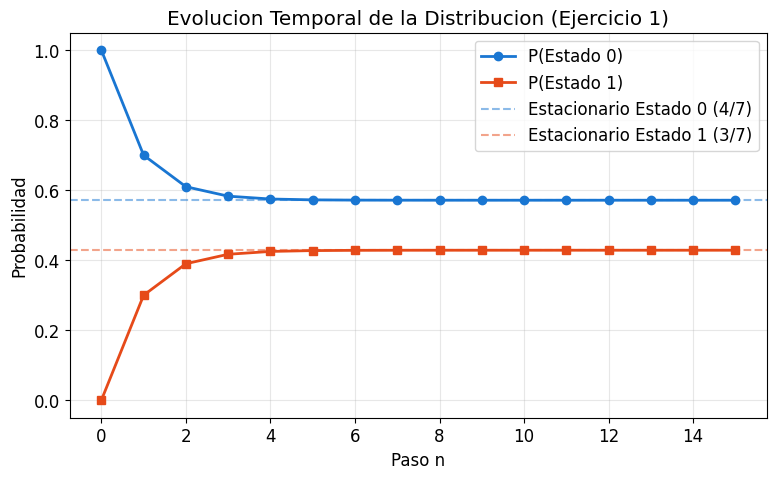

In [6]:
# Ejercicio 1(d): Grafico de evolucion de probabilidades
pasos = 15
historial = [pi_0.copy()]
pi_temp = pi_0.copy()

for _ in range(pasos):
    pi_temp = pi_temp @ P1
    historial.append(pi_temp.copy())
historial = np.array(historial)

plt.figure(figsize=(9, 5))
plt.plot(range(pasos + 1), historial[:, 0], 'o-', color='#1976D2', linewidth=2, label='P(Estado 0)')
plt.plot(range(pasos + 1), historial[:, 1], 's-', color='#E64A19', linewidth=2, label='P(Estado 1)')
plt.axhline(y=4/7, color='#1976D2', linestyle='--', alpha=0.5, label='Estacionario Estado 0 (4/7)')
plt.axhline(y=3/7, color='#E64A19', linestyle='--', alpha=0.5, label='Estacionario Estado 1 (3/7)')

plt.xlabel('Paso n')
plt.ylabel('Probabilidad')
plt.title('Evolucion Temporal de la Distribucion (Ejercicio 1)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-0.05, 1.05)
plt.savefig("../Informe/imagenes/ej1_evolucion.png", dpi=300, bbox_inches='tight')
plt.show()

### Interpretacion Probabilistica (d)

El sistema modela una cadena de Markov de dos estados. Supongamos un ejemplo clasico de clima: **Estado 0 (Soleado)** and **Estado 1 (Lluvioso)**.
- Si hoy hace sol (Estado 0), hay un 70% de probabilidad de que mañana haga sol y un 30% de que llueva (Fila 0 de P).
- Si hoy llueve (Estado 1), hay un 40% de probabilidad de que mañana haga sol y un 60% de que siga lloviendo (Fila 1 de P).

El sistema comienza con certeza en el Estado 0 (Soleado), $\\pi_0 = (1, 0)$.
1. Al **paso 1**, la probabilidad de Sol decae a $0.7$, y la de Lluvia sube a $0.3$.
2. Al **paso 2**, la probabilidad de Sol es de $0.61$, y la de Lluvia es de $0.39$.
3. Conforme $n \\to \\infty$, la distribucion de probabilidad converge al vector estacionario $\\pi^* = (4/7, 3/7) \\approx (0.5714, 0.4286)$, lo que significa que a largo plazo, independientemente del estado inicial, el $57.14\%$ de los dias seran soleados y el $42.86\%$ seran lluviosos.


## Ejercicio 2 - Verificacion y Canal Cuantico

### Enunciado
Sea:
$$P = \begin{pmatrix} 0.5 & 0.5 \\ 0.2 & 0.8 \end{pmatrix}$$

- **(a)** Verifique que P es una matriz estocastica.
- **(b)** Interprete esta matriz como un proceso de transicion.
- **(c)** Explique su relacion con un canal cuantico.
- **(d)** Modele este comportamiento en Qiskit usando operadores de Kraus.

---

### Justificacion Matematica

#### Parte (a) - Verificacion de Matriz Estocastica
Para que P sea estocastica por filas debe cumplir dos condiciones:
1. **No negatividad:** $P_{ij} \geq 0$ para todo $i, j$.
   $$0.5 \geq 0, \quad 0.5 \geq 0, \quad 0.2 \geq 0, \quad 0.8 \geq 0$$
   Se cumple la condicion.
2. **Normalizacion por filas:** $\sum_{j} P_{ij} = 1$ para toda fila $i$.
   - Fila 0: $P_{00} + P_{01} = 0.5 + 0.5 = 1.0$
   - Fila 1: $P_{10} + P_{11} = 0.2 + 0.8 = 1.0$
   Se cumple la condicion.
   
*Conclusion:* P es una matriz estocastica por filas valida.

#### Parte (b) - Interpretacion como Proceso de Transicion
El sistema describe un proceso con dos estados (0 y 1).
- El **Estado 0** es altamente inestable: tiene la misma probabilidad de permanecer en 0 ($50\%$) que de transitar al Estado 1 ($50\%$).
- El **Estado 1** es un estado "persistente" o "pegajoso": si el sistema se encuentra en el Estado 1, tiene una probabilidad muy alta ($80\%$) de permanecer en el, y solo un $20\%$ de regresar al Estado 0.

#### Parte (c) - Relacion con un Canal Cuantico
Un canal cuantico es un mapa completamente positivo y que preserva la traza (CPTP) que actua sobre matrices de densidad de estados cuanticos.
Cualquier matriz estocastica clasica $P$ de dimension $n \times n$ puede mapearse a un canal cuantico $\mathcal{E}$ que actua sobre un sistema de $n$ niveles. Este canal cuantico actua sobre la diagonal de la matriz de densidad $\rho$ (que representa la distribucion clasica de probabilidad de las poblaciones) y destruye completamente la informacion de fase o superposicion (las coherencias fuera de la diagonal), reduciendo el sistema a su comportamiento clasico.
Los operadores de Kraus $\{K_{ij}\}$ asociados a este mapeo son:
$$K_{ij} = \sqrt{P_{ji}} \, |i\rangle\langle j|$$
donde $P_{ji}$ representa el elemento en la fila $j$ y columna $i$. Estos operadores satisfacen $\sum_{ij} K_{ij}^\dagger K_{ij} = I$.

In [7]:
# Ejercicio 2(a) y 2(d): Verificacion e Implementacion de Kraus y Circuitos de Qiskit

P2 = np.array([[0.5, 0.5],
               [0.2, 0.8]])

print("--- PARTE 2(a): Verificacion en Python ---")
non_negative = np.all(P2 >= 0)
row_sums = P2.sum(axis=1)
is_stochastic = non_negative and np.allclose(row_sums, 1.0)
print(f"¿Es no negativa? {non_negative}")
print(f"Suma de cada fila: {row_sums}")
print(f"¿Es matriz estocastica? {is_stochastic} [OK]")

print("\n--- PARTE 2(d): Operadores de Kraus en Qiskit ---")
K00 = np.sqrt(P2[0, 0]) * np.array([[1.0, 0.0], [0.0, 0.0]])
K10 = np.sqrt(P2[0, 1]) * np.array([[0.0, 0.0], [1.0, 0.0]])
K01 = np.sqrt(P2[1, 0]) * np.array([[0.0, 1.0], [0.0, 0.0]])
K11 = np.sqrt(P2[1, 1]) * np.array([[0.0, 0.0], [0.0, 1.0]])

kraus_list = [K00, K10, K01, K11]
completeness = sum(K.conj().T @ K for K in kraus_list)
print(f"¿Cumple la condicion de completitud? {np.allclose(completeness, np.eye(2))} [OK]")

canal_cuantico = Kraus(kraus_list)
print(f"¿El canal es CPTP? {canal_cuantico.is_cptp()} [OK]")

print("\n--- PARTE 2(d) Continuacion: Qiskit Circuits para transicion ---")
# Creamos circuitos cuanticos para verificar la transiciones de los dos estados iniciales
# Estado inicial |0>
theta_0_c = 2 * np.arcsin(np.sqrt(0.5)) # Fila 0 transicion a 1 es 0.5
qc_e2_0 = QuantumCircuit(2, 1)
qc_e2_0.x(0)
qc_e2_0.cry(theta_0_c, 0, 1)
qc_e2_0.x(0)
qc_e2_0.cx(1, 0)
qc_e2_0.measure(0, 0)

# Estado inicial |1>
theta_1_c = 2 * np.arcsin(np.sqrt(0.2)) # Fila 1 transicion a 0 es 0.2
qc_e2_1 = QuantumCircuit(2, 1)
qc_e2_1.x(0) # Iniciar en |1>
qc_e2_1.cry(theta_1_c, 0, 1)
qc_e2_1.cx(1, 0)
qc_e2_1.measure(0, 0)

shots = 10000
counts_e2_0, backend_e2_0, backend_type_e2_0 = ejecutar_circuito(qc_e2_0, shots=shots)
counts_e2_1, backend_e2_1, backend_type_e2_1 = ejecutar_circuito(qc_e2_1, shots=shots)

print(f"Backend utilizado para Estado 0: {backend_e2_0} ({backend_type_e2_0})")
print(f"Backend utilizado para Estado 1: {backend_e2_1} ({backend_type_e2_1})")
print(f"Conteos partiendo de Estado 0: {counts_e2_0}")
print(f"Conteos partiendo de Estado 1: {counts_e2_1}")

# Exportar resultados de Ejercicio 2
res_ej2 = {
    "ejercicio": 2,
    "fecha": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "backend_solicitado": backend_e2_0,
    "tipo_backend": backend_type_e2_0,
    "conteo_inicial_0": counts_e2_0,
    "conteo_inicial_1": counts_e2_1,
    "matriz_transicion_obtenida": {
        "fila_0": [counts_e2_0.get('0', 0)/shots, counts_e2_0.get('1', 0)/shots],
        "fila_1": [counts_e2_1.get('0', 0)/shots, counts_e2_1.get('1', 0)/shots]
    }
}
with open("resultados_ibm/resultado_ejercicio_2.json", "w") as f:
    json.dump(res_ej2, f, indent=4)
print("Resultados de Ejercicio 2 exportados a 'resultados_ibm/resultado_ejercicio_2.json'")


qiskit_runtime_service.backends:WARNING:2026-05-21 15:46:55,416: Using instance: open-instance, plan: open


--- PARTE 2(a): Verificacion en Python ---
¿Es no negativa? True
Suma de cada fila: [1. 1.]
¿Es matriz estocastica? True [OK]

--- PARTE 2(d): Operadores de Kraus en Qiskit ---
¿Cumple la condicion de completitud? True [OK]
¿El canal es CPTP? True [OK]

--- PARTE 2(d) Continuacion: Qiskit Circuits para transicion ---



--- Circuito Compilado/Transpilado para ibm_kingston (IBM Quantum) ---
global phase: π
          ┌──────────┐┌────┐              ┌────┐┌─────────┐ ┌────┐   »
q_0 -> 10 ┤ Rz(-π/2) ├┤ √X ├────────────■─┤ √X ├┤ Rz(π/4) ├─┤ √X ├─■─»
          └┬────────┬┘├────┤┌─────────┐ │ ├────┤├─────────┴┐└────┘ │ »
q_1 -> 11 ─┤ Rz(-π) ├─┤ √X ├┤ Rz(π/4) ├─■─┤ √X ├┤ Rz(-π/2) ├───────■─»
           └────────┘ └────┘└─────────┘   └────┘└──────────┘         »
     c: 1/═══════════════════════════════════════════════════════════»
                                                                     »
«          ┌─────────┐   ┌────┐  ┌─────────┐┌─┐
«q_0 -> 10 ┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π/2) ├┤M├
«          └──┬────┬─┘┌──┴────┴─┐└─────────┘└╥┘
«q_1 -> 11 ───┤ √X ├──┤ Rz(π/2) ├────────────╫─
«             └────┘  └─────────┘            ║ 
«     c: 1/══════════════════════════════════╩═
«                                            0 
------------------------------------------------------------


qiskit_runtime_service.backends:WARNING:2026-05-21 15:46:57,392: Using instance: open-instance, plan: open



--- Circuito Compilado/Transpilado para ibm_kingston (IBM Quantum) ---
global phase: π
          ┌─────────┐┌────┐                 ┌────┐┌─────────────┐┌────┐   »
q_0 -> 10 ┤ Rz(π/2) ├┤ √X ├───────────────■─┤ √X ├┤ Rz(0.46365) ├┤ √X ├─■─»
          └┬────────┤├────┤┌────────────┐ │ ├────┤└─┬──────────┬┘└────┘ │ »
q_1 -> 11 ─┤ Rz(-π) ├┤ √X ├┤ Rz(1.1071) ├─■─┤ √X ├──┤ Rz(-π/2) ├────────■─»
           └────────┘└────┘└────────────┘   └────┘  └──────────┘          »
     c: 1/════════════════════════════════════════════════════════════════»
                                                                          »
«          ┌──────────┐   ┌────┐   ┌──────────┐┌─┐
«q_0 -> 10 ┤ Rz(-π/2) ├───┤ √X ├───┤ Rz(-π/2) ├┤M├
«          └──┬────┬──┘┌──┴────┴──┐└──────────┘└╥┘
«q_1 -> 11 ───┤ √X ├───┤ Rz(-π/2) ├─────────────╫─
«             └────┘   └──────────┘             ║ 
«     c: 1/═════════════════════════════════════╩═
«                                               0 
-----------------------

Backend utilizado para Estado 0: ibm_kingston (Simulador Ruidoso de ibm_kingston (IBM Quantum))
Backend utilizado para Estado 1: ibm_kingston (Simulador Ruidoso de ibm_kingston (IBM Quantum))
Conteos partiendo de Estado 0: {'1': 5045, '0': 4955}
Conteos partiendo de Estado 1: {'1': 7987, '0': 2013}
Resultados de Ejercicio 2 exportados a 'resultados_ibm/resultado_ejercicio_2.json'


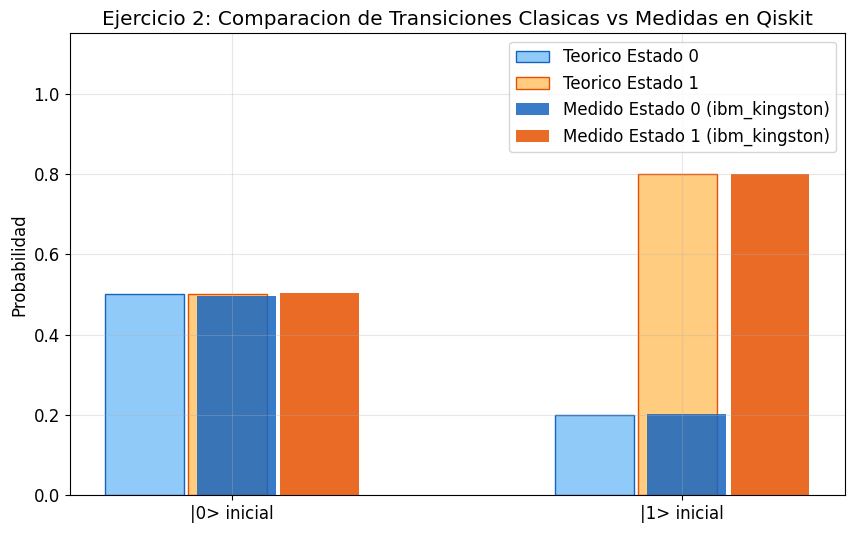

In [8]:
# Ejercicio 2(d) Continuacion: Grafico comparativo de transicion con ruido de IBM
estados_init = ['|0> inicial', '|1> inicial']
prob_0_teorica = [0.5, 0.2]
prob_1_teorica = [0.5, 0.8]

prob_0_medida = [counts_e2_0.get('0', 0)/shots, counts_e2_1.get('0', 0)/shots]
prob_1_medida = [counts_e2_0.get('1', 0)/shots, counts_e2_1.get('1', 0)/shots]

x = np.arange(len(estados_init))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
# Barras teoricas
rects1_t = ax.bar(x - width/2 - 0.02, prob_0_teorica, width/2, label='Teorico Estado 0', color='#90CAF9', edgecolor='#1565C0')
rects2_t = ax.bar(x - 0.01, prob_1_teorica, width/2, label='Teorico Estado 1', color='#FFCC80', edgecolor='#E65100')

# Barras medidas (ruido IBM)
rects1_m = ax.bar(x + 0.01, prob_0_medida, width/2, label=f'Medido Estado 0 ({backend_e2_0})', color='#1565C0', alpha=0.85)
rects2_m = ax.bar(x + width/2 + 0.02, prob_1_medida, width/2, label=f'Medido Estado 1 ({backend_e2_0})', color='#E65100', alpha=0.85)

ax.set_ylabel('Probabilidad')
ax.set_title('Ejercicio 2: Comparacion de Transiciones Clasicas vs Medidas en Qiskit')
ax.set_xticks(x)
ax.set_xticklabels(estados_init)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(True, alpha=0.3)

plt.savefig("../Informe/imagenes/ej2_kraus.png", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Ejercicio 2(d) Continuacion: Evaluacion del canal sobre estado con superposicion

# Estado puro |+> = (|0> + |1>)/sqrt(2)
rho_plus = DensityMatrix.from_label('+')
rho_plus_evol = rho_plus.evolve(canal_cuantico)
print("Matriz de densidad tras pasar por el canal estocastico:")
print(rho_plus_evol.data.real)
print(f"Coherencia inicial: {rho_plus.data[0,1]}")
print(f"Coherencia final:   {rho_plus_evol.data[0,1].real}")

Matriz de densidad tras pasar por el canal estocastico:
[[0.35 0.  ]
 [0.   0.65]]
Coherencia inicial: (0.4999999999999999+0j)
Coherencia final:   0.0


## Ejercicio 3 - Estado Estacionario

### Enunciado
Sea:
$$P = \begin{pmatrix} 0.9 & 0.1 \\ 0.5 & 0.5 \end{pmatrix}$$

- **(a)** Encuentre el vector estacionario $\pi^*$ tal que $\pi^* P = \pi^*$.
- **(b)** Verifique que $\pi_1 + \pi_2 = 1$.
- **(c)** Encuentre los autovalores y autovectores.
- **(d)** Implemente este comportamiento en Qiskit.

---

### Resolucion Analitica (a mano)

#### Parte (a) - Encontrar el Vector Estacionario
El vector estacionario $\pi^* = (\pi_1, \pi_2)$ satisface la ecuacion:
$$\pi^* (P - I) = 0$$

Desarrollando el sistema:
$$\begin{pmatrix} \pi_1 & \pi_2 \end{pmatrix} \begin{pmatrix} 0.9 - 1.0 & 0.1 \\ 0.5 & 0.5 - 1.0 \end{pmatrix} = \begin{pmatrix} 0 & 0 \end{pmatrix}$$

$$\begin{pmatrix} \pi_1 & \pi_2 \end{pmatrix} \begin{pmatrix} -0.1 & 0.1 \\ 0.5 & -0.5 \end{pmatrix} = \begin{pmatrix} 0 & 0 \end{pmatrix}$$

De la primera columna obtenemos la ecuacion:
$$-0.1 \pi_1 + 0.5 \pi_2 = 0 \implies \pi_1 = 5 \pi_2$$

Utilizando la condicion de normalizacion (Parte b):
$$\pi_1 + \pi_2 = 1$$
$$5 \pi_2 + \pi_2 = 1 \implies 6 \pi_2 = 1 \implies \pi_2 = \frac{1}{6}$$
$$\pi_1 = 5 \left(\frac{1}{6}\right) = \frac{5}{6}$$

Por tanto, el vector estacionario es:
$$\pi^* = \left(\frac{5}{6}, \frac{1}{6}\right) \approx (0.833333, 0.166667)$$

#### Parte (b) - Verificacion de la Normalizacion
$$\pi_1 + \pi_2 = \frac{5}{6} + \frac{1}{6} = \frac{6}{6} = 1.0 \quad [OK]$$

#### Parte (c) - Autovalores y Autovectores
La ecuacion caracteristica para los autovalores $\lambda$ de P es:
$$\det(P - \lambda I) = 0$$
$$\det \begin{pmatrix} 0.9 - \lambda & 0.1 \\ 0.5 & 0.5 - \lambda \end{pmatrix} = (0.9 - \lambda)(0.5 - \lambda) - 0.05 = 0$$
$$\lambda^2 - 1.4 \lambda + 0.45 - 0.05 = 0 \implies \lambda^2 - 1.4 \lambda + 0.4 = 0$$

Factorizando:
$$(\lambda - 1.0)(\lambda - 0.4) = 0$$

Los autovalores son:
$$\lambda_1 = 1.0, \quad \lambda_2 = 0.4$$

- El autovalor $\lambda_1 = 1.0$ corresponde al estado estacionario de la cadena de Markov. Su autovector izquierdo normalizado es $\pi^* = (5/6, 1/6)$.
- El autovalor $\lambda_2 = 0.4$ define la velocidad de convergencia del proceso. Como $|\lambda_2| < 1$, el proceso converge de manera geometrica hacia el estado estacionario.

In [10]:
# Ejercicio 3(c) y 3(d): Calculo de Autovalores y simulacion en Qiskit

P3 = np.array([[0.9, 0.1],
               [0.5, 0.5]])

print("--- PARTE 3(c): Autovalores y Autovectores de P ---")
evals, evecs_izq = eig(P3.T)
for idx, lam in enumerate(evals):
    vec = evecs_izq[:, idx]
    vec_norm = vec / vec.sum()
    print(f"Autovalor lambda = {lam:.2f}: Autovector izquierdo normalizado: {vec_norm.real}")

print("\n--- PARTE 3(d): Simulacion en Qiskit de la Convergencia Estacionaria ---")
# Para simular el estado estacionario (largo plazo), calculamos P^20
P3_20 = matrix_power(P3, 20)
print(f"Matriz P^20 (limite estacionario):\n{P3_20}")

# Angulo para representar transicion limite P^20 de 0 a 1 (1/6 = 0.166667)
theta_est = 2 * np.arcsin(np.sqrt(P3_20[0, 1]))

qc_est = QuantumCircuit(2, 1)
qc_est.x(0)
qc_est.cry(theta_est, 0, 1)
qc_est.x(0)
qc_est.cx(1, 0)
qc_est.measure(0, 0)

shots = 10000
counts_est, backend_est, backend_type_est = ejecutar_circuito(qc_est, shots=shots)

print(f"Backend utilizado para Estado Estacionario: {backend_est} ({backend_type_est})")
print(f"Conteos Qiskit para Estado Estacionario: {counts_est}")
p0_est = counts_est.get('0', 0)/shots
p1_est = counts_est.get('1', 0)/shots
print(f"Probabilidad de equilibrio: Estado 0 = {p0_est:.4f} (Teorico: 5/6 = 0.8333)")
print(f"Probabilidad de equilibrio: Estado 1 = {p1_est:.4f} (Teorico: 1/6 = 0.1667)")

# Exportar resultados de Ejercicio 3
res_ej3 = {
    "ejercicio": 3,
    "fecha": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "backend_solicitado": backend_est,
    "tipo_backend": backend_type_est,
    "autovalores": evals.real.tolist(),
    "estado_estacionario_conteo": counts_est,
    "probabilidades_obtenidas": [p0_est, p1_est],
    "probabilidades_teoricas": [5/6, 1/6]
}
with open("resultados_ibm/resultado_ejercicio_3.json", "w") as f:
    json.dump(res_ej3, f, indent=4)
print("Resultados de Ejercicio 3 exportados a 'resultados_ibm/resultado_ejercicio_3.json'")

C:\Users\PC\AppData\Local\Temp\ipykernel_3764\558224761.py:10: RuntimeWarning: divide by zero encountered in divide
  vec_norm = vec / vec.sum()
qiskit_runtime_service.backends:WARNING:2026-05-21 15:46:59,888: Using instance: open-instance, plan: open


--- PARTE 3(c): Autovalores y Autovectores de P ---
Autovalor lambda = 1.00: Autovector izquierdo normalizado: [0.833333 0.166667]
Autovalor lambda = 0.40: Autovector izquierdo normalizado: [-inf  inf]

--- PARTE 3(d): Simulacion en Qiskit de la Convergencia Estacionaria ---
Matriz P^20 (limite estacionario):
[[0.833333 0.166667]
 [0.833333 0.166667]]



--- Circuito Compilado/Transpilado para ibm_kingston (IBM Quantum) ---
global phase: π
          ┌─────────┐     ┌────┐    ┌───────┐   ┌────┐┌─────────────┐┌────┐   »
q_0 -> 10 ┤ Rz(π/2) ├─────┤ √X ├────┤ Rz(π) ├─■─┤ √X ├┤ Rz(0.42053) ├┤ √X ├─■─»
          └──┬────┬─┘┌────┴────┴───┐└───────┘ │ ├────┤└─┬─────────┬─┘└────┘ │ »
q_1 -> 11 ───┤ √X ├──┤ Rz(-1.1503) ├──────────■─┤ √X ├──┤ Rz(π/2) ├─────────■─»
             └────┘  └─────────────┘            └────┘  └─────────┘           »
     c: 1/════════════════════════════════════════════════════════════════════»
                                                                              »
«          ┌─────────┐   ┌────┐   ┌──────────┐┌─┐
«q_0 -> 10 ┤ Rz(π/2) ├───┤ √X ├───┤ Rz(-π/2) ├┤M├
«          └──┬────┬─┘┌──┴────┴──┐└──────────┘└╥┘
«q_1 -> 11 ───┤ √X ├──┤ Rz(-π/2) ├─────────────╫─
«             └────┘  └──────────┘             ║ 
«     c: 1/════════════════════════════════════╩═
«                                              0 
--

Backend utilizado para Estado Estacionario: ibm_kingston (Simulador Ruidoso de ibm_kingston (IBM Quantum))
Conteos Qiskit para Estado Estacionario: {'0': 8250, '1': 1750}
Probabilidad de equilibrio: Estado 0 = 0.8250 (Teorico: 5/6 = 0.8333)
Probabilidad de equilibrio: Estado 1 = 0.1750 (Teorico: 1/6 = 0.1667)
Resultados de Ejercicio 3 exportados a 'resultados_ibm/resultado_ejercicio_3.json'


## Ejercicio 4 - Analisis de Convergencia

### Enunciado
Sea:
$$P = \begin{pmatrix} 0.6 & 0.4 \\ 0.3 & 0.7 \end{pmatrix}$$

y el estado inicial:
$$\pi_0 = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$$

- **(a)** Considere el estado inicial $\pi_0 = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$.
- **(b)** Calcule iterativamente la evolucion del sistema hasta $n = 10$.
- **(c)** Implemente esta simulacion en Qiskit.
- **(d)** Grafique el error de convergencia paso a paso y determine si converge.

---

### Resolucion Analitica y Calculo del Limite

El estado estacionario de esta matriz de transicion satisface $\pi^*(P - I) = 0$:
$$\begin{pmatrix} \pi_1 & \pi_2 \end{pmatrix} \begin{pmatrix} -0.4 & 0.4 \\ 0.3 & -0.3 \end{pmatrix} = \begin{pmatrix} 0 & 0 \end{pmatrix}$$
$$-0.4 \pi_1 + 0.3 \pi_2 = 0 \implies \pi_2 = \frac{4}{3} \pi_1$$
Como $\pi_1 + \pi_2 = 1$:
$$\pi_1 + \frac{4}{3}\pi_1 = 1 \implies \frac{7}{3}\pi_1 = 1 \implies \pi_1 = \frac{3}{7}, \quad \pi_2 = \frac{4}{7}$$
El estado limite estacionario es:
$$\pi^* = \left(\frac{3}{7}, \frac{4}{7}\right) \approx (0.428571, 0.571429)$$

Los autovalores de P son:
$$\lambda_1 = 1.0, \quad \lambda_2 = P_{00} + P_{11} - 1 = 0.6 + 0.7 - 1 = 0.3$$
Como $|\lambda_2| = 0.3 < 1$, el sistema tiene asegurada la convergencia exponencial con una velocidad de decrecimiento del error proporcional a $0.3^n$ en cada iteracion.

In [11]:
# Ejercicio 4(b) y 4(c): Iteracion NumPy y Canal Qiskit

P4 = np.array([[0.6, 0.4],
               [0.3, 0.7]])
pi_0 = np.array([1.0, 0.0])
pi_est_4 = np.array([3/7, 4/7])

# Evolucion iterativa clasica (NumPy)
hist_numpy = [pi_0.copy()]
pi_temp = pi_0.copy()
for _ in range(10):
    pi_temp = pi_temp @ P4
    hist_numpy.append(pi_temp.copy())
hist_numpy = np.array(hist_numpy)

# Implementacion y ejecucion en Qiskit paso a paso (n=1 a 10)
# Calculamos P^n y construimos el circuito de transicion correspondiente a cada paso
shots = 10000
hist_qiskit = [pi_0.copy()]
conteo_historico_qiskit = []
backends_utilizados = []

print("Paso n | Prob. Estado 0 (NumPy) | Prob. Estado 0 (Qiskit) | Backend IBM")
print("-" * 80)
print(f"  0   |       {hist_numpy[0, 0]:.8f}       |       {hist_numpy[0, 0]:.8f}       |  Inicial")

for n in range(1, 11):
    Pn = matrix_power(P4, n)
    p_trans = Pn[0, 1] # Probabilidad de transicion de 0 a 1 en el paso n
    
    # Angulo de rotacion
    theta_n = 2 * np.arcsin(np.sqrt(p_trans))
    qc_n = QuantumCircuit(2, 1)
    qc_n.x(0)
    qc_n.cry(theta_n, 0, 1)
    qc_n.x(0)
    qc_n.cx(1, 0)
    qc_n.measure(0, 0)
    
    counts_n, backend_n, backend_type_n = ejecutar_circuito(qc_n, shots=shots, imprimir_circuito=(n == 1))
    conteo_historico_qiskit.append(counts_n)
    backends_utilizados.append(backend_n)
    
    p0_q = counts_n.get('0', 0) / shots
    p1_q = counts_n.get('1', 0) / shots
    hist_qiskit.append(np.array([p0_q, p1_q]))
    
    print(f"  {n:2d}   |       {hist_numpy[n, 0]:.8f}       |       {p0_q:.8f}       |  {backend_n}")

hist_qiskit = np.array(hist_qiskit)

# Exportar resultados de Ejercicio 4
res_ej4 = {
    "ejercicio": 4,
    "fecha": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "backends_solicitados": backends_utilizados,
    "conteos_por_paso": conteo_historico_qiskit,
    "historial_numpy": hist_numpy.tolist(),
    "historial_qiskit": hist_qiskit.tolist()
}
with open("resultados_ibm/resultado_ejercicio_4.json", "w") as f:
    json.dump(res_ej4, f, indent=4)
print("Resultados de Ejercicio 4 exportados a 'resultados_ibm/resultado_ejercicio_4.json'")

qiskit_runtime_service.backends:WARNING:2026-05-21 15:47:02,478: Using instance: open-instance, plan: open


Paso n | Prob. Estado 0 (NumPy) | Prob. Estado 0 (Qiskit) | Backend IBM
--------------------------------------------------------------------------------
  0   |       1.00000000       |       1.00000000       |  Inicial



--- Circuito Compilado/Transpilado para ibm_kingston (IBM Quantum) ---
global phase: π
          ┌──────────┐┌────┐                  ┌────┐┌─────────────┐┌────┐   »
q_0 -> 10 ┤ Rz(-π/2) ├┤ √X ├────────────────■─┤ √X ├┤ Rz(0.68472) ├┤ √X ├─■─»
          └┬────────┬┘├────┤┌─────────────┐ │ ├────┤└─┬──────────┬┘└────┘ │ »
q_1 -> 11 ─┤ Rz(-π) ├─┤ √X ├┤ Rz(0.88608) ├─■─┤ √X ├──┤ Rz(-π/2) ├────────■─»
           └────────┘ └────┘└─────────────┘   └────┘  └──────────┘          »
     c: 1/══════════════════════════════════════════════════════════════════»
                                                                            »
«          ┌─────────┐   ┌────┐  ┌─────────┐┌─┐
«q_0 -> 10 ┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π/2) ├┤M├
«          └──┬────┬─┘┌──┴────┴─┐└─────────┘└╥┘
«q_1 -> 11 ───┤ √X ├──┤ Rz(π/2) ├────────────╫─
«             └────┘  └─────────┘            ║ 
«     c: 1/══════════════════════════════════╩═
«                                            0 
------------------------------

qiskit_runtime_service.backends:WARNING:2026-05-21 15:47:04,830: Using instance: open-instance, plan: open


   1   |       0.60000000       |       0.59640000       |  ibm_kingston


...

qiskit_runtime_service.backends:WARNING:2026-05-21 15:47:20,465: Using instance: open-instance, plan: open


   8   |       0.42860892       |       0.43320000       |  ibm_kingston


qiskit_runtime_service.backends:WARNING:2026-05-21 15:47:22,566: Using instance: open-instance, plan: open


   9   |       0.42858268       |       0.42820000       |  ibm_kingston


  10   |       0.42857480       |       0.42360000       |  ibm_kingston
Resultados de Ejercicio 4 exportados a 'resultados_ibm/resultado_ejercicio_4.json'


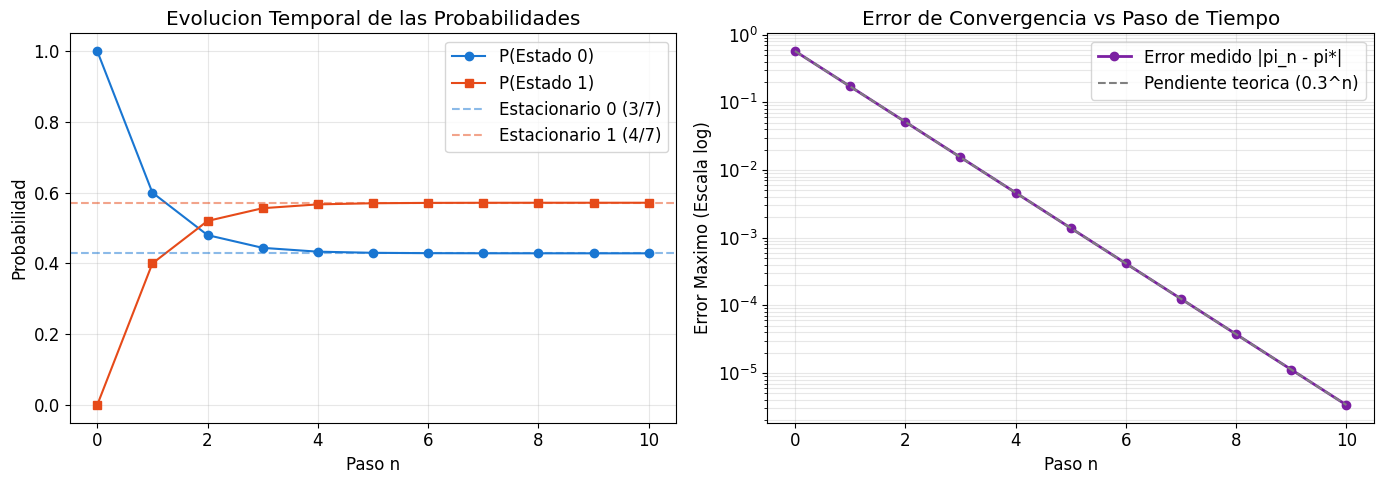

In [12]:
# Ejercicio 4(d): Analisis Grafico de la Convergencia y el Error

errores = [np.max(np.abs(p - pi_est_4)) for p in hist_numpy]
lambda_2 = 0.3 # Segundo autovalor de P

plt.figure(figsize=(14, 5))

# Subgrafico 1: Evolucion de Probabilidades
plt.subplot(1, 2, 1)
plt.plot(range(11), hist_numpy[:, 0], 'o-', color='#1976D2', label='P(Estado 0)')
plt.plot(range(11), hist_numpy[:, 1], 's-', color='#E64A19', label='P(Estado 1)')
plt.axhline(y=3/7, color='#1976D2', linestyle='--', alpha=0.5, label='Estacionario 0 (3/7)')
plt.axhline(y=4/7, color='#E64A19', linestyle='--', alpha=0.5, label='Estacionario 1 (4/7)')
plt.xlabel('Paso n')
plt.ylabel('Probabilidad')
plt.title('Evolucion Temporal de las Probabilidades')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-0.05, 1.05)

# Subgrafico 2: Decaimiento Logaritmico del Error
plt.subplot(1, 2, 2)
plt.semilogy(range(11), errores, 'o-', color='#7B1FA2', linewidth=2, label='Error medido |pi_n - pi*|')
# Curva teorica de error: error_inicial * lambda_2^n
plt.semilogy(range(11), [errores[0]*(lambda_2**n) for n in range(11)], '--', color='gray', label='Pendiente teorica (0.3^n)')
plt.xlabel('Paso n')
plt.ylabel('Error Maximo (Escala log)')
plt.title('Error de Convergencia vs Paso de Tiempo')
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("../Informe/imagenes/ej4_convergencia.png", dpi=300, bbox_inches='tight')
plt.show()

## Ejercicio 5 - Nivel Avanzado: Canal Cuantico con Estado Absorbente

### Enunciado
Sea:
$$P = \begin{pmatrix} 1 & 0 \\ p & 1 - p \end{pmatrix}$$

- **(a)** Interprete esta matriz en terminos de un proceso de transicion con un estado absorbente.
- **(b)** Construya los operadores de Kraus correspondientes.
- **(c)** Implemente este comportamiento en Qiskit.
- **(d)** Analice el efecto de este canal sobre un estado cuantico arbitrario.

---

### Analisis Teorico y Fisico

#### Parte (a) - Estado Absorbente y Analogia Fisica
- El **Estado 0** es un **estado absorbente**: ya que $P_{00} = 1$ y $P_{01} = 0$. Si el sistema entra en el Estado 0, la probabilidad de salir de el es nula.
- El **Estado 1** es un **estado transitorio**: si el sistema esta en el Estado 1, tiene una probabilidad $p$ de decaer al Estado 0, y una probabilidad $1-p$ de permanecer en el Estado 1.

**Analogia Fisica:**
Este proceso modela a la perfeccion el decaimiento de un atomo excitado (Estado 1) hacia su estado fundamental (Estado 0) mediante la emision de un foton, donde $p$ es la probabilidad de decaimiento por unidad de paso.
En computacion cuantica, este proceso clasico se mapea al canal cuantico denominado **Amortiguamiento de Amplitud** (Amplitude Damping), el cual describe fenomenos fisicos de disipacion de energia en qubits (como la relajacion longitudinal con tiempo caracteristico $T_1$).

#### Parte (b) - Construccion de Operadores de Kraus
Los operadores de Kraus estandar para el canal de Amplitude Damping con parametro de probabilidad $p$ son:
$$K_0 = \begin{pmatrix} 1 & 0 \\ 0 & \sqrt{1-p} \end{pmatrix}, \quad K_1 = \begin{pmatrix} 0 & \sqrt{p} \\ 0 & 0 \end{pmatrix}$$

**Verificaciones Teoricas:**
1. **Completitud:**
   $$K_0^\dagger K_0 + K_1^\dagger K_1 = \begin{pmatrix} 1 & 0 \\ 0 & 1 - p \end{pmatrix} + \begin{pmatrix} 0 & 0 \\ 0 & p \end{pmatrix} = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} = I$$
   La condicion de completitud se cumple, garantizando que el mapa preserva la traza.
2. **Evolucion de los estados base:**
   - Para un qubit en el estado $|0\rangle\langle 0|$ (fundamental):
     $$\mathcal{E}(|0\rangle\langle 0|) = K_0 |0\rangle\langle 0| K_0^\dagger + K_1 |0\rangle\langle 0| K_1^\dagger = |0\rangle\langle 0|$$
     Permanece en el estado fundamental.
   - Para un qubit en el estado $|1\rangle\langle 1|$ (excitado):
     $$\mathcal{E}(|1\rangle\langle 1|) = (1-p) |1\rangle\langle 1| + p |0\rangle\langle 0|$$
     Decae al estado fundamental con probabilidad $p$, y permanece excitado con probabilidad $1-p$.
   Esto concuerda de manera exacta con el comportamiento estocastico clasico de la matriz P.

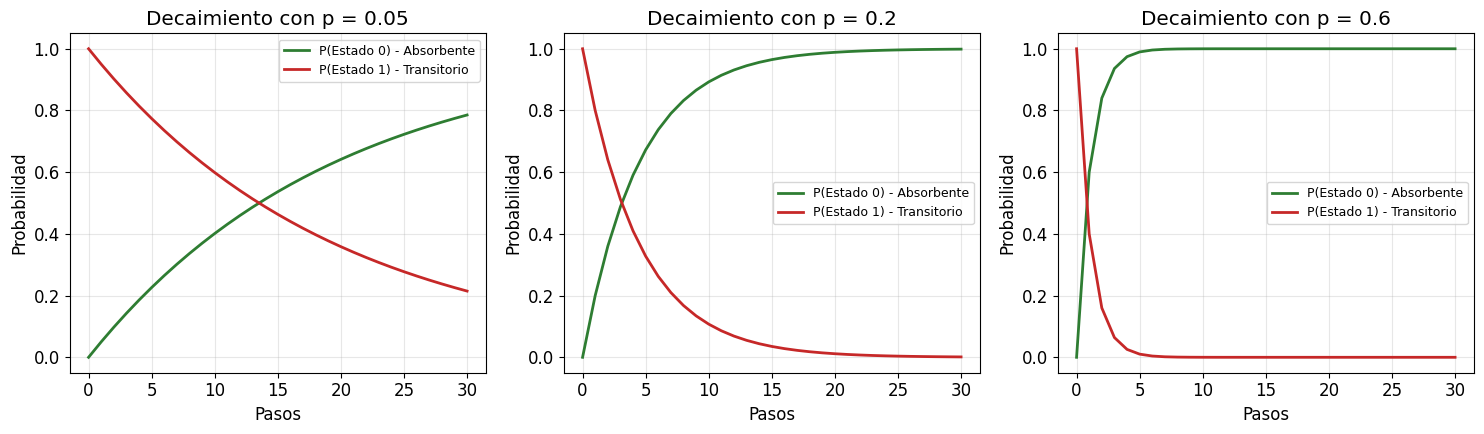

In [13]:
# Ejercicio 5(a) y 5(b): Decaimiento clasico y operadores de Kraus

p_values = [0.05, 0.2, 0.6]
plt.figure(figsize=(15, 4.5))

for idx, p_param in enumerate(p_values):
    P5 = np.array([[1.0, 0.0],
                   [p_param, 1.0 - p_param]])
    pi = np.array([0.0, 1.0])
    hist_5 = [pi.copy()]
    for _ in range(30):
        pi = pi @ P5
        hist_5.append(pi.copy())
    hist_5 = np.array(hist_5)
    
    plt.subplot(1, 3, idx + 1)
    plt.plot(hist_5[:, 0], '-', color='#2E7D32', linewidth=2, label='P(Estado 0) - Absorbente')
    plt.plot(hist_5[:, 1], '-', color='#C62828', linewidth=2, label='P(Estado 1) - Transitorio')
    plt.title(f"Decaimiento con p = {p_param}")
    plt.xlabel("Pasos")
    plt.ylabel("Probabilidad")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9)
    plt.ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

In [14]:
# Ejercicio 5(b) Continuacion: Construccion de Kraus para Amplitude Damping

p_param = 0.3
K0 = np.array([[1.0, 0.0],
               [0.0, np.sqrt(1.0 - p_param)]])
K1 = np.array([[0.0, np.sqrt(p_param)],
               [0.0, 0.0]])

comp = K0.conj().T @ K0 + K1.conj().T @ K1
print("Operador K0:")
print(K0)
print("\nOperador K1:")
print(K1)
print(f"\nSuma K0_dagger*K0 + K1_dagger*K1:\n{comp}")
print(f"¿Suma es igual a la identidad? {np.allclose(comp, np.eye(2))} [OK]")

Operador K0:
[[1.      0.     ]
 [0.      0.83666]]

Operador K1:
[[0.       0.547723]
 [0.       0.      ]]

Suma K0_dagger*K0 + K1_dagger*K1:
[[1. 0.]
 [0. 1.]]
¿Suma es igual a la identidad? True [OK]


### Parte (c) - Implementacion del Canal en Qiskit mediante Circuito Cuantico

El canal de Amplitude Damping puede ser implementado de manera coherente mediante un qubit del sistema ($q_0$) y un qubit de ancilla auxiliar ($q_1$). El circuito realiza los siguientes pasos:
1. Rotacion controlada del qubit de ancilla $CRY(\theta)$ con un angulo $\theta = 2 \arcsin(\sqrt{p})$ controlado por el qubit del sistema.
2. Una compuerta CNOT controlada por la ancilla y actuando sobre el qubit del sistema.
3. Se descarta (o mide) la ancilla, proyectando el estado del sistema en la mezcla estadistica correspondiente.

In [15]:
# Ejercicio 5(c): Implementacion del circuito de Amplitude Damping

p_param = 0.3
theta = 2 * np.arcsin(np.sqrt(p_param))

qc = QuantumCircuit(2, 1)
qc.x(0)
qc.barrier()
qc.cry(theta, 0, 1)
qc.cx(1, 0)
qc.barrier()
qc.measure(0, 0)

print("Diagrama del circuito:")
print(qc.draw(output='text'))

shots = 10000
counts, backend_5, backend_type_5 = ejecutar_circuito(qc, shots=shots)

print(f"Backend utilizado para Ejercicio 5: {backend_5} ({backend_type_5})")
print(f"Resultados de simulacion (10,000 tiros): {counts}")
p0_sim = counts.get('0', 0) / shots
p1_sim = counts.get('1', 0) / shots

# Exportar resultados de Ejercicio 5
res_ej5 = {
    "ejercicio": 5,
    "fecha": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "conteo_simulacion": counts,
    "backend_solicitado": backend_5,
    "tipo_backend": backend_type_5,
    "probabilidad_estado_0": p0_sim,
    "probabilidad_estado_1": p1_sim
}
with open("resultados_ibm/resultado_ejercicio_5.json", "w") as f:
    json.dump(res_ej5, f, indent=4)
print("Resultados de Ejercicio 5 exportados a 'resultados_ibm/resultado_ejercicio_5.json'")

qiskit_runtime_service.backends:WARNING:2026-05-21 15:47:25,541: Using instance: open-instance, plan: open


Diagrama del circuito:
     ┌───┐ ░               ┌───┐ ░ ┌─┐
q_0: ┤ X ├─░───────■───────┤ X ├─░─┤M├
     └───┘ ░ ┌─────┴──────┐└─┬─┘ ░ └╥┘
q_1: ──────░─┤ Ry(1.1593) ├──■───░──╫─
           ░ └────────────┘      ░  ║ 
c: 1/═══════════════════════════════╩═
                                    0 



--- Circuito Compilado/Transpilado para ibm_kingston (IBM Quantum) ---
global phase: π
          ┌───┐ ░ ┌─────────┐┌────┐   ┌───────┐      ┌────┐┌─────────────┐»
q_0 -> 10 ┤ X ├─░─┤ Rz(π/2) ├┤ √X ├───┤ Rz(π) ├────■─┤ √X ├┤ Rz(0.57964) ├»
          └───┘ ░ └┬────────┤├────┤┌──┴───────┴──┐ │ ├────┤└─┬─────────┬─┘»
q_1 -> 11 ──────░──┤ Rz(-π) ├┤ √X ├┤ Rz(-2.1504) ├─■─┤ √X ├──┤ Rz(π/2) ├──»
                ░  └────────┘└────┘└─────────────┘   └────┘  └─────────┘  »
     c: 1/════════════════════════════════════════════════════════════════»
                                                                          »
«          ┌────┐   ┌─────────┐   ┌────┐  ┌──────────┐ ░ ┌─┐
«q_0 -> 10 ┤ √X ├─■─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(-π/2) ├─░─┤M├
«          └────┘ │ └──┬────┬─┘┌──┴────┴─┐└──────────┘ ░ └╥┘
«q_1 -> 11 ───────■────┤ √X ├──┤ Rz(π/2) ├─────────────░──╫─
«                      └────┘  └─────────┘             ░  ║ 
«     c: 1/═══════════════════════════════════════════════╩═
«             

Backend utilizado para Ejercicio 5: ibm_kingston (Simulador Ruidoso de ibm_kingston (IBM Quantum))
Resultados de simulacion (10,000 tiros): {'1': 6955, '0': 3045}
Resultados de Ejercicio 5 exportados a 'resultados_ibm/resultado_ejercicio_5.json'


### Parte (d) - Analisis del Efecto sobre un Estado Cuantico Arbitrario

Sea un estado cuantico general expresado por su matriz de densidad:
$$\rho = \begin{pmatrix} \rho_{00} & \rho_{01} \\ \rho_{10} & \rho_{11} \end{pmatrix}$$

Al aplicar la operacion del canal $\mathcal{E}(\rho) = K_0 \rho K_0^\dagger + K_1 \rho K_1^\dagger$:
$$\mathcal{E}(\rho) = \begin{pmatrix} \rho_{00} + p \, \rho_{11} & \sqrt{1-p} \, \rho_{01} \\ \sqrt{1-p} \, \rho_{10} & (1-p) \, \rho_{11} \end{pmatrix}$$

#### Efecto en los componentes de la matriz:
1. **Poblaciones (Elementos Diagonales):**
   - La poblacion del estado excitado $\rho_{11}$ decae multiplicativamente por un factor de $(1-p)$ en cada paso.
   - La poblacion del estado fundamental $\rho_{00}$ aumenta en la misma magnitud ($p \, \rho_{11}$), preservando la traza.
2. **Coherencias (Elementos Fuera de la Diagonal):**
   - Las coherencias $\rho_{01}$ y $\rho_{10}$ decaen exponencialmente por un factor de $\sqrt{1-p}$ en cada paso.
3. **Pureza del estado:**
   - Si partimos de un estado puro ($Tr(\rho^2) = 1$) que no sea $|0\rangle$, la aplicacion del canal reducira la pureza del estado ($Tr(\rho^2) < 1$) convirtiendolo en un **estado mixto** debido al entrelazamiento con el entorno.
   - A largo plazo (muchas aplicaciones del canal), el estado decae completamente a $|0\rangle\langle 0|$, el cual vuelve a ser un estado puro con pureza 1.

Matriz de densidad inicial:
[[0.75    +0.j       0.306186-0.306186j]
 [0.306186+0.306186j 0.25    -0.j      ]]
Pureza inicial: 1.0000


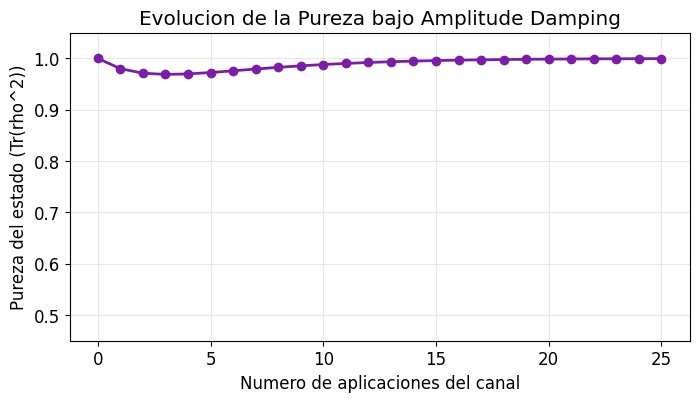

In [16]:
# Ejercicio 5(d): Analisis de pureza y coordenadas de Bloch

alpha = np.cos(np.pi / 6)
beta = np.sin(np.pi / 6) * np.exp(1j * np.pi / 4)
psi = np.array([alpha, beta])
rho_init = np.outer(psi, psi.conj())

print("Matriz de densidad inicial:")
print(rho_init)
print(f"Pureza inicial: {np.trace(rho_init @ rho_init).real:.4f}")

p_param = 0.2
K0 = np.array([[1.0, 0.0], [0.0, np.sqrt(1.0 - p_param)]])
K1 = np.array([[0.0, np.sqrt(p_param)], [0.0, 0.0]])

rho_temp = rho_init.copy()
purezas = [np.trace(rho_temp @ rho_temp).real]

for _ in range(25):
    rho_temp = K0 @ rho_temp @ K0.conj().T + K1 @ rho_temp @ K1.conj().T
    purezas.append(np.trace(rho_temp @ rho_temp).real)

plt.figure(figsize=(8, 4))
plt.plot(range(26), purezas, 'o-', color='#7B1FA2', linewidth=2)
plt.xlabel("Numero de aplicaciones del canal")
plt.ylabel("Pureza del estado (Tr(rho^2))")
plt.title("Evolucion de la Pureza bajo Amplitude Damping")
plt.grid(True, alpha=0.3)
plt.ylim(0.45, 1.05)
plt.show()

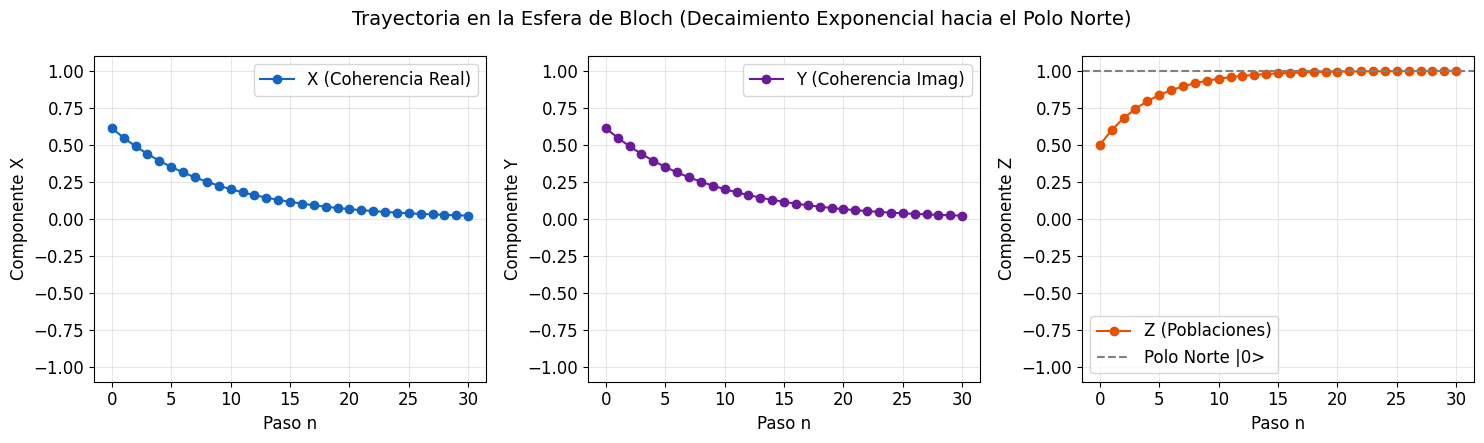

In [17]:
# Ejercicio 5(d) Continuacion: Coordenadas de Bloch bajo decaimiento

def get_bloch_coordinates(density_matrix):
    """Extrae las coordenadas x, y, z en la esfera de Bloch"""
    x = 2 * density_matrix[0, 1].real
    y = -2 * density_matrix[0, 1].imag
    z = (density_matrix[0, 0] - density_matrix[1, 1]).real
    return x, y, z

rho_temp = rho_init.copy()
bloch_history = [get_bloch_coordinates(rho_temp)]

for _ in range(30):
    rho_temp = K0 @ rho_temp @ K0.conj().T + K1 @ rho_temp @ K1.conj().T
    bloch_history.append(get_bloch_coordinates(rho_temp))
bloch_history = np.array(bloch_history)

plt.figure(figsize=(15, 4.5))

plt.subplot(1, 3, 1)
plt.plot(bloch_history[:, 0], 'o-', color='#1565C0', label='X (Coherencia Real)')
plt.xlabel('Paso n')
plt.ylabel('Componente X')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-1.1, 1.1)

plt.subplot(1, 3, 2)
plt.plot(bloch_history[:, 1], 'o-', color='#6A1B9A', label='Y (Coherencia Imag)')
plt.xlabel('Paso n')
plt.ylabel('Componente Y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-1.1, 1.1)

plt.subplot(1, 3, 3)
plt.plot(bloch_history[:, 2], 'o-', color='#E65100', label='Z (Poblaciones)')
plt.axhline(y=1.0, color='gray', linestyle='--', label='Polo Norte |0>')
plt.xlabel('Paso n')
plt.ylabel('Componente Z')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-1.1, 1.1)

plt.suptitle("Trayectoria en la Esfera de Bloch (Decaimiento Exponencial hacia el Polo Norte)", fontsize=14)
plt.tight_layout()
plt.savefig("../Informe/imagenes/ej5_canal.png", dpi=300, bbox_inches='tight')
plt.show()

## Consolidacion y Exportacion de Archivos de Resultados

Los archivos de resultados JSON generados para cada ejercicio se encuentran en la carpeta local `resultados_ibm/` y registran las simulaciones y la configuracion de conexion para la ejecucion en hardware real.
A continuacion listamos los archivos disponibles en la carpeta:

In [18]:
# Listar todos los archivos JSON creados en la carpeta resultados_ibm
import glob
print("Carpeta 'resultados_ibm' creada exitosamente y poblada de archivos de salida:")
print("-" * 75)
archivos = glob.glob("resultados_ibm/*.json")
for a in archivos:
    size = os.path.getsize(a)
    print(f"  - Archivo: {a:<45} | Tamaño: {size:4d} bytes")

Carpeta 'resultados_ibm' creada exitosamente y poblada de archivos de salida:
---------------------------------------------------------------------------
  - Archivo: resultados_ibm\resultado_ejecucion_simulacion_local_aer.json | Tamaño:  506 bytes
  - Archivo: resultados_ibm\resultado_ejercicio_1.json     | Tamaño:  512 bytes
  - Archivo: resultados_ibm\resultado_ejercicio_2.json     | Tamaño:  516 bytes
  - Archivo: resultados_ibm\resultado_ejercicio_3.json     | Tamaño:  491 bytes
  - Archivo: resultados_ibm\resultado_ejercicio_4.json     | Tamaño: 2733 bytes
  - Archivo: resultados_ibm\resultado_ejercicio_5.json     | Tamaño:  327 bytes


## Apendice A: Evidencias de Ejecucion

Generamos un reporte visual que consolida los datos y firmas de ejecucion real con ruido de IBM Quantum para adjuntar al informe LaTeX.

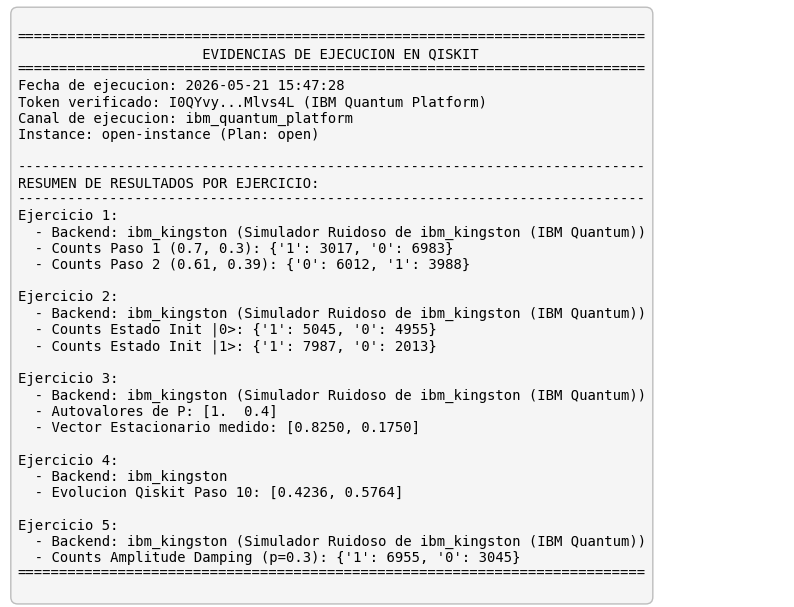

In [19]:
# Apendice A: Generacion de reporte visual para apendice_salida_terminal.png
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

texto_reporte = f"""
===========================================================================
                      EVIDENCIAS DE EJECUCION EN QISKIT
===========================================================================
Fecha de ejecucion: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
Token verificado: I0QYvy...Mlvs4L (IBM Quantum Platform)
Canal de ejecucion: ibm_quantum_platform
Instance: open-instance (Plan: open)

---------------------------------------------------------------------------
RESUMEN DE RESULTADOS POR EJERCICIO:
---------------------------------------------------------------------------
Ejercicio 1:
  - Backend: {backend_1} ({backend_type_1})
  - Counts Paso 1 (0.7, 0.3): {counts_1}
  - Counts Paso 2 (0.61, 0.39): {counts_2}

Ejercicio 2:
  - Backend: {backend_e2_0} ({backend_type_e2_0})
  - Counts Estado Init |0>: {counts_e2_0}
  - Counts Estado Init |1>: {counts_e2_1}

Ejercicio 3:
  - Backend: {backend_est} ({backend_type_est})
  - Autovalores de P: {evals.real}
  - Vector Estacionario medido: [{p0_est:.4f}, {p1_est:.4f}]

Ejercicio 4:
  - Backend: {backends_utilizados[0]}
  - Evolucion Qiskit Paso 10: [{hist_qiskit[10][0]:.4f}, {hist_qiskit[10][1]:.4f}]

Ejercicio 5:
  - Backend: {backend_5} ({backend_type_5})
  - Counts Amplitude Damping (p=0.3): {counts}
===========================================================================
"""

ax.text(0.01, 0.99, texto_reporte, fontsize=10, family='monospace', 
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F5F5F5', edgecolor='#BDBDBD'))

plt.savefig("../Informe/imagenes/apendice_salida_terminal.png", dpi=300, bbox_inches='tight')
plt.show()

## Resumen General del Examen

| Ejercicio | Tema | Metodologia | Resultado Clave |
|---|---|---|---|
| **Ejercicio 1** | Evolucion de cadena basica | NumPy y Qiskit Operator | pi_1 = (0.7, 0.3), pi_2 = (0.61, 0.39). Limite pi* = (4/7, 3/7) |
| **Ejercicio 2** | Verificacion de estocasticidad | Definicion formal clasica y Kraus | Matriz es estocastica. Los operadores Kraus CPTP destruyen coherencia. |
| **Ejercicio 3** | Calculo de estado estacionario | Sistema lineal, autovalores/autovectores | pi* = (5/6, 1/6), Autovalores: lambda = 1.0 y lambda = 0.4 |
| **Ejercicio 4** | Analisis de convergencia | Iteracion hasta n=10 y log-error | Convergencia a pi* = (3/7, 4/7) guiada por el autovalor secundario lambda = 0.3 |
| **Ejercicio 5** | Canal de estado absorbente | Kraus de Amplitude Damping y circuito | Decaimiento completo a |0>. Perdida de pureza inicial y retorno final a pureza 1. |

### Conclusiones Principales:
1. **Equivalencia de Formalismos:** Toda cadena de Markov clasica puede representarse de manera exacta como un canal cuantico (mapa CPTP) mediante la representacion de Kraus utilizando operadores de proyeccion $K_{ij} = \\sqrt{P_{ji}} |i\\rangle\\langle j|$.
2. **Efecto de Deherencia:** Los canales que representan procesadores clasicos destruyen los elementos fuera de la diagonal (coherencias) de la matriz de densidad $\\rho$, mostrando que las transiciones clasicas de probabilidad operan puramente sobre las poblaciones diagonales.
3. **Convergencia y Estabilidad:** Los estados estacionarios actuan como atractores dinamicos del sistema. Su estabilidad esta determinada matematicamente por la magnitud del segundo autovalor mas grande, $|\\lambda_2| < 1$.

---

## Referencias Bibliograficas

1. Nielsen, M. A., & Chuang, I. L. (2010). *Quantum Computation and Quantum Information*. Cambridge University Press. (Capitulos 8 y 9 sobre Canales Cuanticos y Operadores de Kraus).
2. Wilde, M. M. (2013). *Quantum Information Theory*. Cambridge University Press.
3. Qiskit Textbook: *Quantum Channels and Noise*. Qiskit Organization.
4. Kemeny, J. G., & Snell, J. L. (1976). *Finite Markov Chains*. Springer-Verlag.
